## File preprocessing mean features
Corridor forelimps left + right 

- *Load packages*

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
import plotly.express as px
from pandas import read_csv
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


- *Load dataset for left and right forelimb*

In [2]:
# Load the datasets
#df_forelimb_left = pd.read_csv("/Users/asm/Desktop/UNI/MasterThesis/data/final/cvae_data/Corridor_forelimb_Left_mouse_features_2026_02_05_09_18_02.csv")
#df_forelimb_right = pd.read_csv("/Users/asm/Desktop/UNI/MasterThesis/data/final/cvae_data/Corridor_forelimb_Rightmouse_features_2026_02_05_15_29_42.csv")

df_forelimb_left = pd.read_csv("/Users/asm/Desktop/UNI/MasterThesis/data/final/cvae_data/Corridor_forelimb_Left_mouse_features_2025-10-28_18-59-15.csv")
df_forelimb_right = pd.read_csv("/Users/asm/Desktop/UNI/MasterThesis/data/final/cvae_data/Corridor_forelimb_Right_mouse_features_2025-10-28_16-00-11.csv")


- *Merge files*

In [3]:
# Tag each file with its side
left = df_forelimb_left.assign(Side="left")
right = df_forelimb_right.assign(Side="right")

print(f"Total Left rows:  {len(left)}")
print(f"Total Right rows: {len(right)}")
print("-" * 30)

# Combine all data
df_forelimb = pd.concat([left, right], ignore_index=True)

# Extract person name and mouse number
df_forelimb[['Person', 'Mouse']] = df_forelimb['Mouse'].str.extract(r'(\w+)_Mouse(\d+)')
df_forelimb['Mouse'] = pd.to_numeric(df_forelimb['Mouse'])

# Wide-form: Match Dataset/Person/Mouse colums from left and right + Numeric columns become ..._left / ..._right
        # This performs an 'Outer Join' (keeps everything, fills missing sides with NaN)
wide = (df_forelimb
        .set_index(["Dataset", "Person", "Mouse", "Side"])
        .sort_index()
        .unstack("Side"))

wide.columns = [f"{col}_{side}" for col, side in wide.columns]
wide = wide.reset_index()
#df_forelimb_combined = wide

# Discard mice with missing side 
complete_matches = wide.dropna()
df_forelimb_combined = complete_matches

# Calculate pairs
num_complete = len(complete_matches)
num_total_wide = len(wide)
print(f"Total rows after merge: {num_total_wide}")
print(f"Complete pairs (both Left & Right):  {num_complete}")
print("-" * 30)

# Print name of discarded mice
check_col_left = [c for c in wide.columns if c.endswith('_left')][0]
check_col_right = check_col_left.replace('_left', '_right')
missing_right_side = wide[wide[check_col_right].isna()]
missing_left_side = wide[wide[check_col_left].isna()]
print(f"Discarded: Present in left, missing in right ({len(missing_right_side)})")
if not missing_right_side.empty:
    # Printing specific columns to identify the file/mouse
    print(missing_right_side[['Person', 'Mouse']].to_string(index=False))
else:
    print("None.")
print(f"Discarded: Present in right, missing in left ({len(missing_left_side)})")
if not missing_left_side.empty:
    print(missing_left_side[['Person', 'Mouse']].to_string(index=False))
else:
    print("None.")
print("-" * 30)

print(f"Final dataframe size (clean pairs only): {len(df_forelimb_combined)}")

Total Left rows:  325
Total Right rows: 323
------------------------------
Total rows after merge: 325
Complete pairs (both Left & Right):  323
------------------------------
Discarded: Present in left, missing in right (2)
Person  Mouse
 Elisa     58
 Elisa     60
Discarded: Present in right, missing in left (0)
None.
------------------------------
Final dataframe size (clean pairs only): 323


- *Create injury label*

In [4]:
# Define the set of mice that should be labeled as "Severe" (defined by the test performer)
severe_mice1 = {2, 12, 26, 34, 56, 58, 88, 112, 114, 130, 152, 166, 168, 172, 178, 180, 190, 192}   # 2 weeks post SCI
severe_mice2 = {34, 88, 114, 166, 180, 192}                                                         # 8 weeks post SCI 
severe_mice3 = {204, 240, 250, 258}                                                                 # 10 weeks post SCI

# Create the 'Injury' column
df = df_forelimb_combined
df["Injury"] = np.nan
df["Injury"] = df["Injury"].astype(object)

# Assign "Healthy" if 'Dataset' contains 'PreSCI'
df.loc[df["Dataset"].str.contains("PreSCI", case=False, na=False), "Injury"] = "Healthy"

# Assign "Severe" 2 weeks
df.loc[
    (df["Dataset"].str.contains(r"2w(Post)?SCI|2weeks?PostSCI", case=False, na=False)) &
    (df["Mouse"].isin(severe_mice1)),
    "Injury"
] = "Severe"

# Assign "Severe" 8 weeks
df.loc[
    (df["Dataset"].str.contains(r"8w(Post)?SCI|8weeks?PostSCI", case=False, na=False)) &
    (df["Mouse"].isin(severe_mice2)),
    "Injury"
] = "Severe"

# Assign "Severe" 8 weeks
df.loc[
    (df["Dataset"].str.contains(r"10w(Post)?SCI|10weeks?PostSCI", case=False, na=False)) &
    (df["Mouse"].isin(severe_mice3)),
    "Injury"
] = "Severe"

# Replace remaining NaN with "Unlabelled"
df["Injury"] = df["Injury"].fillna("Unlabelled")
#df["Injury"] = df["Injury"].fillna(-1)

# Reorder columns
cols = ['Dataset','Person', 'Mouse', 'Injury'] + [col for col in df.columns if col not in ['Dataset','Person', 'Mouse', 'Injury']]
df = df[cols]

print(df["Injury"].value_counts(), "\n")
print(df.groupby("Dataset")["Injury"].value_counts(), "\n")

weeks = [2, 8, 10, 16]
for w in weeks:
    count = df["Dataset"].str.contains(fr"{w}w(?:Post)?SCI|{w}weeks?PostSCI", case=False, na=False).sum()
    print(f"{w}-week: {count}")

Injury
Unlabelled    200
Healthy        95
Severe         28
Name: count, dtype: int64 

Dataset                        Injury    
Nimo_2weeksPostSCI             Unlabelled    10
                               Severe         4
Nimo_8weeksPostSCI             Unlabelled    10
                               Severe         2
Nimo_PreSCI                    Healthy       14
Placebo_2weeksPostSCI          Unlabelled    15
                               Severe         5
Placebo_8weeksPostSCI          Unlabelled    17
                               Severe         2
Placebo_PreSCI                 Healthy       20
TrainedBaclofen_2weeksPostSCI  Unlabelled    18
                               Severe         2
TrainedBaclofen_8weeksPostSCI  Unlabelled    20
TrainedBaclofen_PreSCI         Healthy       20
TrainedNimoLate_10wPostSCI     Unlabelled    10
                               Severe         2
TrainedNimoLate_16wPostSCI     Unlabelled    12
TrainedNimo_2weeksPostSCI      Unlabelled    16
     

/var/folders/2l/4g96dftd11584kr3dkj86nnm0000gn/T/ipykernel_36965/4008745984.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Injury"] = np.nan
/var/folders/2l/4g96dftd11584kr3dkj86nnm0000gn/T/ipykernel_36965/4008745984.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Injury"] = df["Injury"].astype(object)
/var/folders/2l/4g96dftd11584kr3dkj86nnm0000gn/T/ipykernel_36965/4008745984.py:16: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the 

- *Cosine/sine transformation on degree features*
- *Standardize features*

The features are of different scales (cm/s, degrees, cm), so StandardScaler() normalize them to a comparabel range, so one feature dosnt dominate the other. 

In [5]:
# Cosine/sine transformation

# Define substrings to search for
angle_keywords = [
    "mean angle value",
    "mean angle during stance",
    "mean angle during swing",
    "mean propulsion vector angle ",
    "mean phase value",
    "mean phase during stance",
    "mean phase during swing"
]

for col in df.columns:
    if any(keyword in col.lower() for keyword in angle_keywords):
        df[col + '_sin'] = np.sin(np.deg2rad(df[col]))  
        df[col + '_cos'] = np.cos(np.deg2rad(df[col])) 
        # Remove the original column
        df = df.drop(columns=[col])

# Store identifiers (not scaled)
identifiers = df[["Dataset","Mouse", "Person", "Injury"]].reset_index(drop=True)

# Drop unwanted columns and scale
df_numeric = df.drop(columns=["Dataset", "Mouse", "Person", "Injury",
                              "Number of runs (#)_left",
                              "Number of runs (#)_right",
                              "Number of steps (#)_right",
                              "Number of steps (#)_left",],
                    errors="ignore")

# Data set scaled with a zero mean and unit variance
df_numeric = df_numeric.select_dtypes(include=["number"])
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numeric)

# Combine scaled data and identifiers
df_scaled = pd.DataFrame(df_scaled, columns=df_numeric.columns)
df_scaled = pd.concat([identifiers, df_scaled], axis=1)

/var/folders/2l/4g96dftd11584kr3dkj86nnm0000gn/T/ipykernel_36965/3610054981.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col + '_sin'] = np.sin(np.deg2rad(df[col]))
/var/folders/2l/4g96dftd11584kr3dkj86nnm0000gn/T/ipykernel_36965/3610054981.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col + '_cos'] = np.cos(np.deg2rad(df[col]))
/var/folders/2l/4g96dftd11584kr3dkj86nnm0000gn/T/ipykernel_36965/3610054981.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the resu

- *Mutual Information (MI)*

- *Plot the ratios of the MI*

Total samples: 323
Labeled samples: 123
Unlabeled samples: 200


Number of features before: 5796
Number of features after: 3251
Number of features dropped: 2545


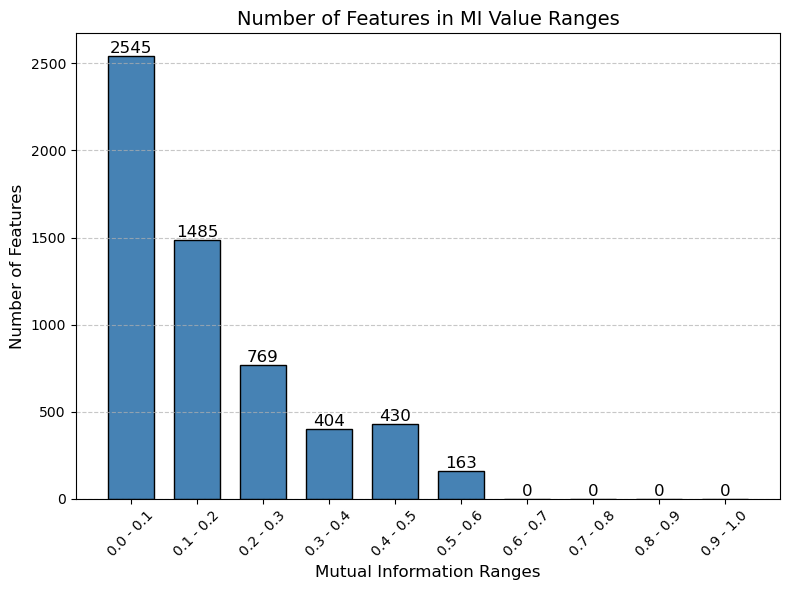

In [6]:
# Number of features
X = df_scaled.drop(columns=["Dataset", "Mouse", "Person", "Injury"]) 
num_features_before = X.shape[1]

# Map labels
label_mapping = {"Healthy": 0, "Severe": 1}
df_scaled["Injury_Label"] = df_scaled["Injury"].map(label_mapping).fillna(-1).astype(int)

# Reorder columns
cols = ['Dataset', 'Mouse', 'Person', 'Injury', 'Injury_Label'] + \
       [col for col in df_scaled.columns if col not in ['Dataset', 'Mouse', 'Person', 'Injury', 'Injury_Label']]
df_scaled = df_scaled[cols]

y = df_scaled["Injury_Label"]  

# Keep only labeled samples for MI calculation
labeled_mask = df_scaled["Injury_Label"] != -1

print(f"Total samples: {len(df_scaled)}")
print(f"Labeled samples: {labeled_mask.sum()}")
print(f"Unlabeled samples: {(~labeled_mask).sum()}\n")

#print(df_scaled["Injury_Label"].value_counts())

X_labeled = X[labeled_mask]
y_labeled = y[labeled_mask]

#print(f"X_labeled shape: {X_labeled.shape}")
#print(f"y_labeled shape: {y_labeled.shape}")

# Calculate Mutual Information only on labeled data
mi = mutual_info_classif(X_labeled, y_labeled)

# Create a DataFrame to inspect MI values
mi_df = pd.DataFrame(mi, index=X.columns, columns=["Mutual Information"])
mi_df = mi_df.sort_values(by="Mutual Information", ascending=False)

# Select a threshold for MI 
threshold = 0.1  

# Select features with MI above the threshold
selected_features = mi_df[mi_df["Mutual Information"] >= threshold].index

num_features_after = len(selected_features)
dropped_features = num_features_before - num_features_after

print(f"\nNumber of features before: {num_features_before}")
print(f"Number of features after: {num_features_after}")
print(f"Number of features dropped: {dropped_features}")

# Filter your original dataframe to keep only the selected features
X_selected = X[selected_features]
df_selected = pd.concat([df_scaled[["Dataset", "Mouse", "Person", "Injury", "Injury_Label"]], X_selected], axis=1)

# Assume mi_scores is your array of Mutual Information values
mi_scores = mi  

# Define bins and labels
bin_edges = np.arange(0, 1.1, 0.1)
bin_labels = [f'{bin_edges[i]:.1f} - {bin_edges[i+1]:.1f}' for i in range(len(bin_edges)-1)]
feature_counts, _ = np.histogram(mi_scores, bins=bin_edges)

# Plot using Matplotlib
plt.figure(figsize=(8, 6))
bars = plt.bar(bin_labels, feature_counts, color='steelblue', edgecolor='black', width=0.7)

# Add MI counts above bars
for bar, count in zip(bars, feature_counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(count),
        ha='center', va='bottom',
        fontsize=12, color='black'
    )

# Add gridlines, titles, etc.
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title("Number of Features in MI Value Ranges", fontsize=14)
plt.xlabel("Mutual Information Ranges", fontsize=12)
plt.ylabel("Number of Features", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

# Save (optional)
# plt.savefig("file/path/MI_scaled.png", dpi=300)

plt.show()


In [7]:
""" # --- REPLACEMENT FOR MI SECTION ---

# 1. Create the Injury_Label (Required for the next section)
# This logic was previously inside the MI block, so we must keep it here.
label_mapping = {"Healthy": 0, "Severe": 1}
df_scaled["Injury_Label"] = df_scaled["Injury"].map(label_mapping).fillna(-1).astype(int)

# 2. Reorder columns to ensure Identifiers are first
# This ensures consistency with how 'df_selected' looked previously
cols = ['Dataset', 'Mouse', 'Person', 'Injury', 'Injury_Label'] + \
       [col for col in df_scaled.columns if col not in ['Dataset', 'Mouse', 'Person', 'Injury', 'Injury_Label']]
df_scaled = df_scaled[cols]

# 3. Skip Feature Selection
# Instead of filtering by threshold, we simply copy the full dataframe.
df_selected = df_scaled.copy()

print(f"MI Selection skipped.")
print(f"Total features retained: {df_selected.shape[1] - 5}") # -5 for the identifier cols

# --- END REPLACEMENT --- """

' # --- REPLACEMENT FOR MI SECTION ---\n\n# 1. Create the Injury_Label (Required for the next section)\n# This logic was previously inside the MI block, so we must keep it here.\nlabel_mapping = {"Healthy": 0, "Severe": 1}\ndf_scaled["Injury_Label"] = df_scaled["Injury"].map(label_mapping).fillna(-1).astype(int)\n\n# 2. Reorder columns to ensure Identifiers are first\n# This ensures consistency with how \'df_selected\' looked previously\ncols = [\'Dataset\', \'Mouse\', \'Person\', \'Injury\', \'Injury_Label\'] +        [col for col in df_scaled.columns if col not in [\'Dataset\', \'Mouse\', \'Person\', \'Injury\', \'Injury_Label\']]\ndf_scaled = df_scaled[cols]\n\n# 3. Skip Feature Selection\n# Instead of filtering by threshold, we simply copy the full dataframe.\ndf_selected = df_scaled.copy()\n\nprint(f"MI Selection skipped.")\nprint(f"Total features retained: {df_selected.shape[1] - 5}") # -5 for the identifier cols\n\n# --- END REPLACEMENT --- '

In [8]:
# Counting the number of new mice in dataset compared to the old
col = df_scaled['Mouse']
df_ids = (
    pd.to_numeric(col, errors='coerce')      # turn strings to numbers, invalid -> NaN
      .dropna()
      .astype(int)
)
df_set = set(df_ids.tolist())

# Number of existing mice
existing_mice = [108, 124, 188, 144, 160, 128, 116, 196, 170, 182, 194, 48, 10, 68, 140, 66, 198, 106, 162, 80, 176, 136, 184,
                   20, 120, 146, 150, 174, 122, 90, 84, 50, 70, 102, 8, 76, 40, 38, 72, 64, 24, 52, 18, 42, 16, 82, 138, 132, 74,
                   110, 134, 118, 104, 186, 100, 62, 142, 86, 22, 36, 30, 44, 6, 60, 154, 4, 164, 54, 32, 28, 46, 14, 158, 156,
                   78, 2, 12, 26, 34, 58, 88, 166, 180, 56, 114, 112, 130, 190, 152, 168, 172, 178, 192, 126, 148]
existing_set = set(int(x) for x in existing_mice)

# Comparison
new_in_candidates = sorted(existing_set - df_set)   
already_existing  = sorted(existing_set & df_set)   
missing_from_list = sorted(df_set - existing_set)  

print(f"Total number of unique mice IDs in new df: {len(df_set)}")
print(f"Total number of unique mice IDs in old df: {len(existing_set)}")
print(f"Already existing, overlab: {len(already_existing)} -> {already_existing[:20]}{'...' if len(already_existing)>20 else ''}")
print(f"Number of mice exsiting in old data, but not present in new: {len(new_in_candidates)} -> {new_in_candidates}")
print(f"Number of mice in the new data, not exsiting in old: {len(missing_from_list)} -> {missing_from_list[:30]}{'...' if len(missing_from_list)>30 else ''}")


Total number of unique mice IDs in new df: 119
Total number of unique mice IDs in old df: 95
Already existing, overlab: 95 -> [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40]...
Number of mice exsiting in old data, but not present in new: 0 -> []
Number of mice in the new data, not exsiting in old: 24 -> [202, 204, 206, 208, 212, 214, 216, 218, 220, 222, 226, 232, 234, 236, 238, 240, 242, 244, 246, 248, 250, 256, 258, 260]


- *Include asym columns*

In [9]:
# Extract features (x) and labels
x_array = df_selected.drop(columns=['Dataset', 'Mouse', 'Person', 'Injury', 'Injury_Label']).values.astype(np.float32)
y_array = df_selected["Injury_Label"].values.astype(int)

# Convert to torch tensors
x_tensor = torch.tensor(x_array, dtype=torch.float32)
y_tensor = torch.tensor(y_array, dtype=torch.long)

labeled_mask = y_tensor != -1 # -1 used for unlabeled rows.

# Include covariets, new mice are not assigned
df_scaled_with_asym = df_selected.copy()

# Mice in different clusters, prior groupings only used to create (c).
cluster_3_mice = [108, 124, 188, 144, 160, 128, 116, 196, 170, 182, 194, 48, 10, 68, 140, 66, 198, 106, 162, 80, 176, 136, 184]
cluster_4_mice = [20, 120, 146] 
cluster_5_mice = [150, 174, 122, 90] 
cluster_2_mice = [84, 50, 70, 102, 8, 76, 40, 38, 72, 64, 24, 52, 18, 42, 16, 82, 138, 132, 74, 110, 134, 118, 104, 186, 100, 62, 142, 86, 22, 36, 30, 44, 6, 60, 154, 4, 164, 54, 32, 28, 46, 14, 158, 156, 78] # 56

def assign_cluster(mouse_id, injury_label):
    if injury_label == 0:
        return 0  # Healthy
    elif injury_label == 1:
        return 1  # Severe paralysis include {2, 12, 26, 34, 58, 88, 166, 180} {56, 114, 112, 130, 190, 152, 168, 172, 178, 192}
    elif mouse_id in cluster_3_mice:
        return 3
    elif mouse_id in cluster_4_mice:
        return 4
    elif mouse_id in cluster_5_mice:
        return 5
    elif mouse_id in cluster_2_mice:
        return 2
    else:
        return -1  # Unknown or not assigned include {126, 148, 202, 204, 206, 208, 212, 214, 216, 218, 220, 222, 226, 232, 234, 236, 238, 240, 242, 244, 246, 248, 250, 256, 258, 260}

df_scaled_with_asym["Cluster"] = df_scaled_with_asym.apply(
    lambda row: assign_cluster(row["Mouse"], row["Injury_Label"]),
    axis=1
)

def assign_asymmetry(cluster, injury_label):
    if injury_label == 0:
        return [0, 0, 0]  # Healthy
    elif cluster == 3:
        return [0, 1, 0]  # Right
    elif cluster == 5:
        return [1, 0, 0]  # Left
    elif cluster in [4, 1]:
        return [0, 0, 1]  # Bilateral
    elif cluster == 2:
        return [0, 0, 1]  # Mild bilateral
    else:
        return [0, 0, 0]  # Unknown

df_scaled_with_asym[["Asym_L", "Asym_R", "Asym_B"]] = df_scaled_with_asym.apply(
    lambda row: pd.Series(assign_asymmetry(row["Cluster"], row["Injury_Label"])),
    axis=1
)

In [10]:
new_ids = [202, 204, 206, 208, 212, 214, 216, 218, 220, 222, 
           226, 232, 234, 236, 238, 240, 242, 244, 246, 248, 
           250, 256, 258, 260]

# Ensure column type matches the IDs (e.g. int)
df_scaled_with_asym['Mouse'] = pd.to_numeric(df_scaled_with_asym['Mouse'], errors='coerce')

# Filter the rows
new_mice_rows = df_scaled_with_asym[df_scaled_with_asym['Mouse'].isin(new_ids)]

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(new_mice_rows[['Mouse', 'Dataset', 'Injury', 'Injury_Label']])


     Mouse                        Dataset      Injury  Injury_Label
159    212     TrainedNimoLate_10wPostSCI  Unlabelled            -1
160    214     TrainedNimoLate_10wPostSCI  Unlabelled            -1
161    216     TrainedNimoLate_10wPostSCI  Unlabelled            -1
162    218     TrainedNimoLate_10wPostSCI  Unlabelled            -1
163    220     TrainedNimoLate_10wPostSCI  Unlabelled            -1
164    234     TrainedNimoLate_10wPostSCI  Unlabelled            -1
165    236     TrainedNimoLate_10wPostSCI  Unlabelled            -1
166    238     TrainedNimoLate_10wPostSCI  Unlabelled            -1
167    240     TrainedNimoLate_10wPostSCI      Severe             1
168    256     TrainedNimoLate_10wPostSCI  Unlabelled            -1
169    258     TrainedNimoLate_10wPostSCI      Severe             1
170    260     TrainedNimoLate_10wPostSCI  Unlabelled            -1
171    212     TrainedNimoLate_16wPostSCI  Unlabelled            -1
172    214     TrainedNimoLate_16wPostSCI  Unlab

### Clean dataset for NaN values
-*Check if there is NaN values in the dataset*

In [11]:
# Does the data contain any NaN values
df_scaled_with_asym.isna().any().any() # Returns True if there is at least one NaN anywhere in the DataFrame, and False if there are no NaNs.

False

In [12]:
# Display rows that contain NaN values
df_scaled_with_asym[df_scaled_with_asym.isna().any(axis=1)]

,Dataset,Mouse,Person,Injury,Injury_Label,Mean step acceleration X during stance - ankle std_right,Mean step acceleration Y during stance - ankle std_left,Mean angle velocity during stance - rhindlimb - hip (rad/s)_right,Mean phase value - rhindlimb - knee std_right_sin,Mean phase value - rhindlimb - knee std_right_cos,...,Mean phase acceleration at swing - spine - spine 1 (rad/s^2)_right,Mean phase velocity at touchdown - rhindlimb - ankle std_left,Mean angle during stance - rhindlimb - lHindpaw std_right_sin,Mean step jerk X at stance - knee (m/s^3)_left,Mean step jerk Y at stance - spine 4 std_left,Mean angle during swing - tail - tail 1 std_left_sin,Cluster,Asym_L,Asym_R,Asym_B


Nimo_8weeksPostSCI	58 and 60 dosnt have any data from the right side, so these two rows are removed. 

In [13]:
before = len(df_scaled_with_asym)
df_scaled_with_asym = df_scaled_with_asym.dropna()
after = len(df_scaled_with_asym)

print(f"Removed {before - after} rows containing NaN values.\n")
print("Cleaned dataset.")

Removed 0 rows containing NaN values.

Cleaned dataset.


In [14]:
df_scaled_with_asym.isna().any().any()
# Should print: False

False

- *Save*

In [15]:
df_scaled_with_asym.to_csv("/Users/asm/Desktop/UNI/MasterThesis/data/final/cvae_data/preprocessed_datafile_cvae.csv", index=False)
print(f"Done saved csv.")

Done saved csv.
